In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers
from tensorflow.keras import Model
import tensorflow as tf

In [2]:
df = pd.read_csv('../../data/clean/emotion_dataset.csv')
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [3]:

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 13999
Validation: 3001
Test: 3000


In [4]:
X_train = train_df["text"]
y_train = train_df["label"]

X_val = val_df["text"]
y_val = val_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [5]:
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_val = tokenizer.texts_to_sequences(X_val)
X_test = tokenizer.texts_to_sequences(X_test)

X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_val = pad_sequences(X_val, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

In [6]:


class PositionalEmbedding(tf.keras.layers.Layer):

    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(
            vocab_size,
            d_model
        )

        self.pos_embedding = tf.keras.layers.Embedding(
            max_len,
            d_model
        )

    def call(self, x):

        length = tf.shape(x)[1]

        positions = tf.range(
            start=0,
            limit=length,
            delta=1
        )

        return (
            self.embedding(x)
            + self.pos_embedding(positions)
        )

In [7]:
class TransformerEncoder(tf.keras.layers.Layer):

    def __init__(
        self,
        embed_dim,
        num_heads,
        ff_dim,
        rate=0.1
    ):
        super().__init__()

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim)
        ])

        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs):

        attn_output = self.att(
            inputs,
            inputs
        )

        attn_output = self.dropout1(attn_output)

        out1 = self.norm1(
            inputs + attn_output
        )

        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(ffn_output)

        return self.norm2(
            out1 + ffn_output
        )

## Construir el modelo

In [8]:
VOCAB_SIZE = 20000
MAX_LEN = 100

EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 256

NUM_CLASSES = 6

In [9]:
inputs = layers.Input(shape=(MAX_LEN,))

x = PositionalEmbedding(
    VOCAB_SIZE,
    EMBED_DIM,
    MAX_LEN
)(inputs)

x = TransformerEncoder(
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM
)(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dropout(0.2)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenamiento del modelo

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [12]:
#history = model.fit(
   # X_train,
    #y_train,
    #validation_data=(X_val, y_val),
    #epochs=10,
    #batch_size=32
#)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.3857 - loss: 1.5001 - val_accuracy: 0.7844 - val_loss: 0.7245
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.8820 - loss: 0.3640 - val_accuracy: 0.8917 - val_loss: 0.2888
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.9251 - loss: 0.1960 - val_accuracy: 0.8880 - val_loss: 0.3194
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9524 - loss: 0.1274 - val_accuracy: 0.8814 - val_loss: 0.3845


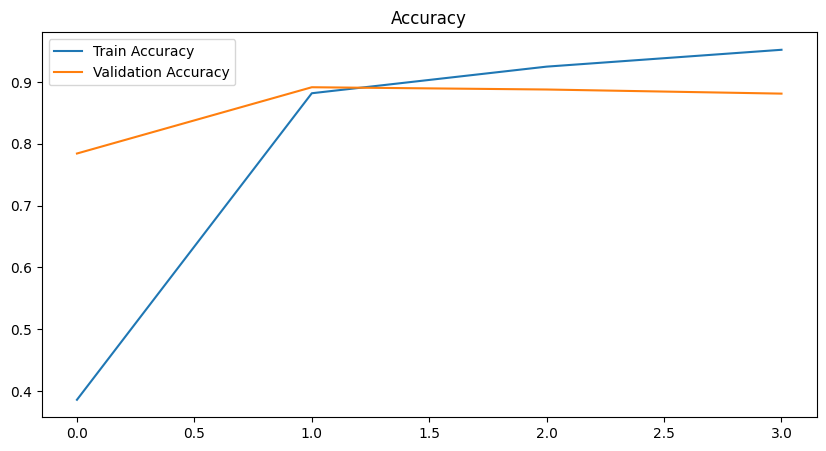

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

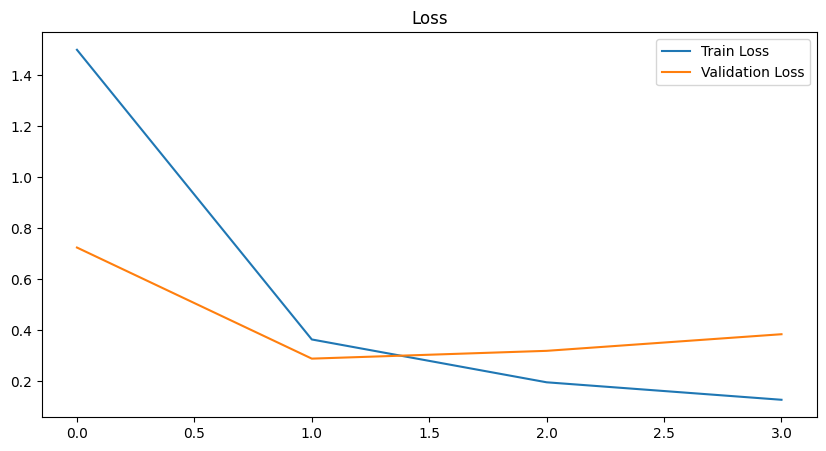

In [15]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9043 - loss: 0.2550
Test Accuracy: 0.9043
Test Loss: 0.2550


In [17]:
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9043
Precision: 0.9076
Recall   : 0.9043
F1 Score : 0.9049


In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       870
           1       0.92      0.92      0.92      1014
           2       0.74      0.88      0.80       246
           3       0.93      0.89      0.91       406
           4       0.86      0.91      0.88       356
           5       0.89      0.69      0.78       108

    accuracy                           0.90      3000
   macro avg       0.88      0.87      0.87      3000
weighted avg       0.91      0.90      0.90      3000



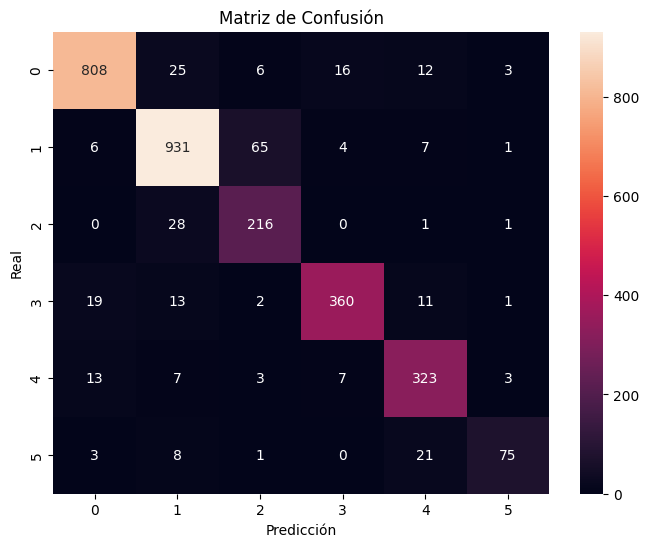

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()